In [6]:
import numpy as np
import polymer_pl as pp
import matplotlib.pyplot as plt

temperature = 300  # K

Angle1 = np.array([ -3.94, 3.94, 16.5, 14.8, -14.8, -16.5])
rotation1 = [0, 1, 0, 2, 0, 1]
Angle2 = np.array([-3.94, 3.94, 16.5, 14.8, -14.8, -16.5])
rotation2 = [0, 1, 0, 3, 0, 1]
labels = {
    1: {'loc': 'AIID-T.txt', 'color': 'b'},
    2: {'loc': 'T-T.txt', 'color': 'm'},
    3: {'loc': 'FT-FT.txt', 'color': 'c'},
}

In [7]:
p1 = pp.PolymerPersistence(bond_lengths=None,
                           bond_angles_deg=Angle1,
                           temperature=temperature,
                           rotation_types=rotation1,
                           rotation_labels=labels)
p2 = pp.PolymerPersistence(bond_lengths=None,
                           bond_angles_deg=Angle2,
                           temperature=temperature,
                           rotation_types=rotation2,
                           rotation_labels=labels)

In [12]:
matrix1 = p1.matrix
matrix2 = p2.matrix
lp_repeats = pp.compute_persistence_terpolymer([matrix1,matrix2], [0.5, 0.5])

print(f"Persistence length (in repeat units) = {lp_repeats:.6f}")

Persistence length (in repeat units) = 10.221959


Persistence Length in Repeats for Terpolymer:
11.87314 (probability = 0.00)
11.67705 (probability = 0.05)
11.48894 (probability = 0.10)
11.30833 (probability = 0.15)
11.13481 (probability = 0.20)
10.96798 (probability = 0.25)
10.80745 (probability = 0.30)
10.65289 (probability = 0.35)
10.50398 (probability = 0.40)
10.36043 (probability = 0.45)
10.22196 (probability = 0.50)
10.08831 (probability = 0.55)
9.95923 (probability = 0.60)
9.83452 (probability = 0.65)
9.71394 (probability = 0.70)
9.59732 (probability = 0.75)
9.48446 (probability = 0.80)
9.37518 (probability = 0.85)
9.26934 (probability = 0.90)
9.16676 (probability = 0.95)
9.06731 (probability = 1.00)


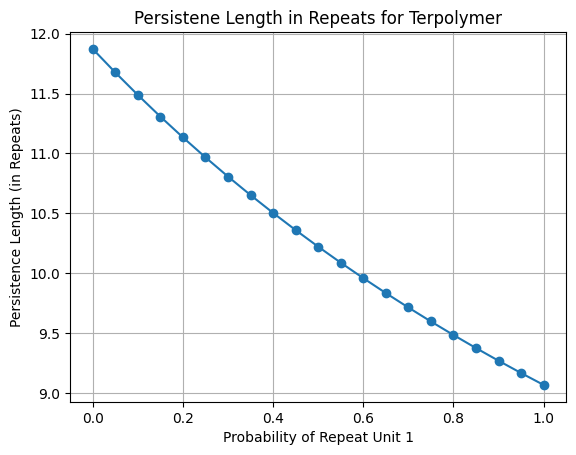

In [13]:
# scan 0-1
probs = np.linspace(0, 1, 21)
N_p =  [pp.compute_persistence_terpolymer([matrix1, matrix2], [x, 1-x]) for x in probs]
plt.plot(probs, N_p, 'o-')
plt.title("Persistene Length in Repeats for Terpolymer")
plt.xlabel("Probability of Repeat Unit 1")
plt.ylabel("Persistence Length (in Repeats)")
plt.grid(True)

all_np = [f"{num:.5f} (probability = {prob:.2f})" for num, prob in zip(np.array(N_p), probs)]
print("Persistence Length in Repeats for Terpolymer:", )
print("\n".join(all_np))

Persistence Length in Repeats for Terpolymer:
10.22196 (Temperature = 300.00 K)
9.35077 (Temperature = 320.00 K)
8.64653 (Temperature = 340.00 K)
8.06800 (Temperature = 360.00 K)
7.58608 (Temperature = 380.00 K)
7.17970 (Temperature = 400.00 K)
6.83334 (Temperature = 420.00 K)
6.53529 (Temperature = 440.00 K)
6.27665 (Temperature = 460.00 K)
6.05049 (Temperature = 480.00 K)
5.85138 (Temperature = 500.00 K)
5.67498 (Temperature = 520.00 K)
5.51783 (Temperature = 540.00 K)
5.37711 (Temperature = 560.00 K)
5.25050 (Temperature = 580.00 K)
5.13609 (Temperature = 600.00 K)
5.03230 (Temperature = 620.00 K)
4.93778 (Temperature = 640.00 K)
4.85143 (Temperature = 660.00 K)
4.77227 (Temperature = 680.00 K)
4.69950 (Temperature = 700.00 K)


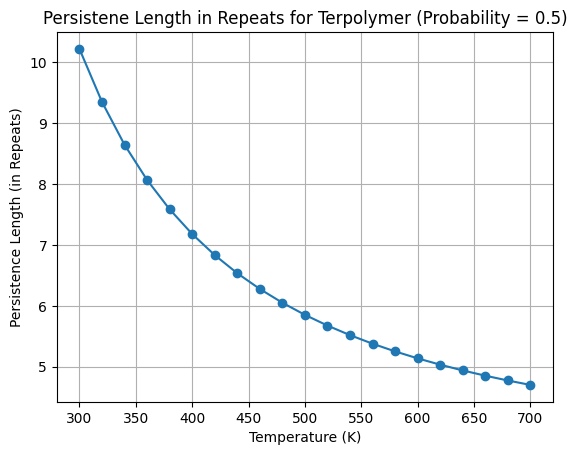

In [14]:
# scan temperaturem, prob = 0.5
temperatures = np.linspace(300, 700, 21)
Np_temperature = []
for temp in temperatures:
    p1 = pp.PolymerPersistence(bond_lengths=None,
                           bond_angles_deg=Angle1,
                           temperature=temp,
                           rotation_types=rotation1,
                           rotation_labels=labels)
    p2 = pp.PolymerPersistence(bond_lengths=None,
                            bond_angles_deg=Angle2,
                            temperature=temp,
                            rotation_types=rotation2,
                            rotation_labels=labels)
    lp_repeats = pp.compute_persistence_terpolymer([p1.matrix, p2.matrix], [0.5, 0.5])
    Np_temperature.append(lp_repeats)
plt.plot(temperatures, Np_temperature, 'o-')
plt.title("Persistene Length in Repeats for Terpolymer (Probability = 0.5)")
plt.xlabel("Temperature (K)")
plt.ylabel("Persistence Length (in Repeats)")
plt.grid(True)

all_np = [f"{num:.5f} (Temperature = {t:.2f} K)" for num, t in zip(Np_temperature, temperatures)]
print("Persistence Length in Repeats for Terpolymer:", )
print("\n".join(all_np))

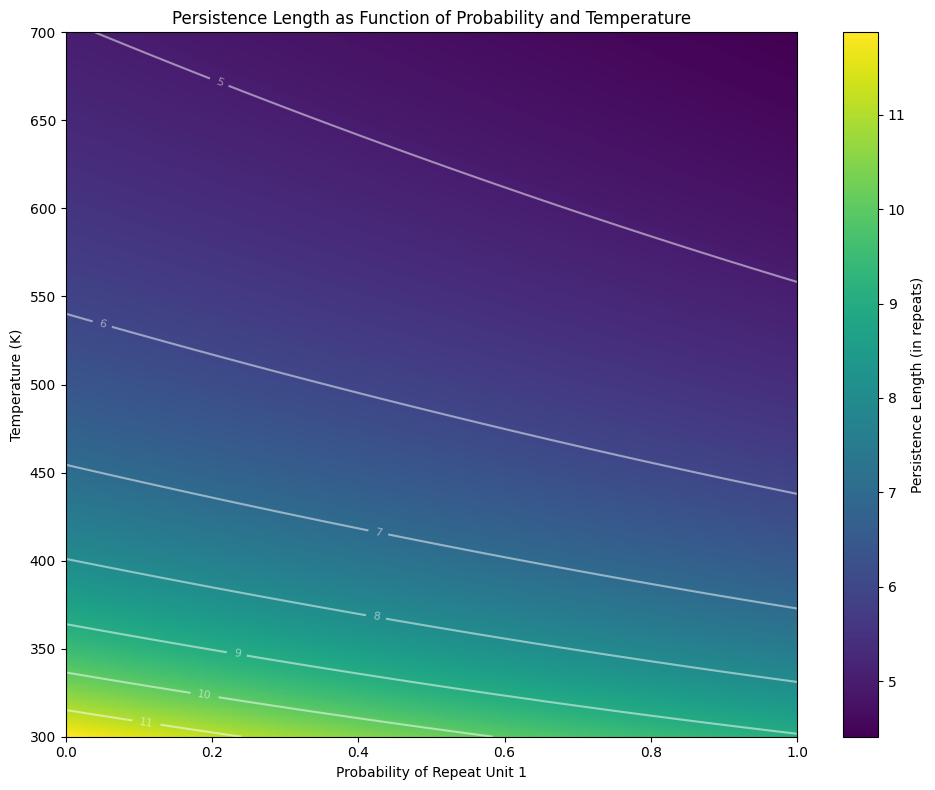

In [15]:
# scan both temperature and prob
temperatures_2d = np.linspace(300, 700, 401)
probs_2d = np.linspace(0, 1, 101)
lp_grid = np.zeros((len(temperatures_2d), len(probs_2d)))
for i, temp in enumerate(temperatures_2d):
    # Create matrices for this temperature
    p1 = pp.PolymerPersistence(bond_lengths=None,
                           bond_angles_deg=Angle1,
                           temperature=temp,
                           rotation_types=rotation1,
                           rotation_labels=labels)
    p2 = pp.PolymerPersistence(bond_lengths=None,
                            bond_angles_deg=Angle2,
                            temperature=temp,
                            rotation_types=rotation2,
                            rotation_labels=labels)
    
    for j, prob in enumerate(probs_2d):
        lp_repeats = pp.compute_persistence_terpolymer([p1.matrix, p2.matrix], [prob, 1-prob])
        lp_grid[i, j] = lp_repeats
plt.figure(figsize=(10, 8))
plt.imshow(lp_grid,
           extent=[
               probs_2d[0], probs_2d[-1], temperatures_2d[-1],
               temperatures_2d[0]
           ],
           aspect='auto',
           cmap='viridis')
plt.colorbar(label='Persistence Length (in repeats)')
plt.xlabel('Probability of Repeat Unit 1')
plt.ylabel('Temperature (K)')
plt.title('Persistence Length as Function of Probability and Temperature')
plt.gca().invert_yaxis() # To have lower temperatures at the bottom
contours = plt.contour(probs_2d, temperatures_2d, lp_grid, colors='white', alpha=0.5)
plt.clabel(contours, inline=True, fontsize=8)

plt.tight_layout()